Assignment3_Bank_Regression

This project examines the performance of different regression methodologies under a controlled simulation framework. By implementing both classical linear regression and penalized regression techniques, we evaluate coefficient estimation accuracy, model robustness, and the impact of shrinkage. Additionally, we explore non-linear modeling and illustrate the bias–variance trade-off to understand how model flexibility affects generalization.

## Section 1: Data Simulation and Linear Regression

Data Generating Mechanism and Rationale

We construct a synthetic dataset with n = 300 observations and p = 10 predictors.  
The underlying data generating mechanism (DGM) is defined as:

y = beta0 + sum(beta_j * X_j) + epsilon

### Choice of Coefficients

To evaluate the model’s ability to distinguish informative predictors from irrelevant ones, coefficients are assigned different magnitudes:

**Strong Signals (beta1 = 3, beta2 = -2.5, beta3 = 1.8)**  
These predictors represent the primary structural drivers of the response variable.  
Their relatively large magnitude ensures a clear signal that should be consistently detected by the regression model.

**Moderate Signals (beta4 = 0.5, beta5 = -0.3)**  
These coefficients are non-zero but small.  
They represent realistic situations where effects exist but are subtle, making statistical detection more challenging.

**Noise Variables (beta6 to beta10 = 0)**  
These predictors have no true effect on the response.  
They are included to test whether the regression model incorrectly assigns statistical significance to irrelevant features.

### Role of Random Error

The disturbance term is assumed to follow:

epsilon ~ Normal(0, sigma^2) with sigma = 1.5

**Justification of Normality:**  
The error term represents the combined influence of many unobserved factors.  
By the Central Limit Theorem, the sum of many small independent effects tends to follow a normal distribution.

**Importance for Inference:**  
Without the random error term, the relationship between X and y would be perfectly deterministic.  
Adding noise makes the outcome stochastic, requiring statistical inference (such as hypothesis testing) to distinguish true effects from random variation.

In [3]:
import numpy as np

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Global Configuration
np.random.seed(123)  # Fixed seed for reproducibility
plt.style.use('seaborn-v0_8-whitegrid')

# 1.1 Data Generation
n = 300
p = 10
sigma = 1.5  # Noise standard deviation

# Generate Predictors (X)
X = np.random.normal(0, 1, size=(n, p))
column_names = [f'X{i+1}' for i in range(p)]
df_X = pd.DataFrame(X, columns=column_names)

# Define True Parameters
beta_true = np.array([3.0, -2.5, 1.8, 0.5, -0.3, 0.0, 0.0, 0.0, 0.0, 0.0])
intercept_true = 1.0

# Generate Response (y)
noise = np.random.normal(0, sigma, size=n)
y = np.dot(X, beta_true) + intercept_true + noise

# Store in DataFrame
df = df_X.copy()
df['y'] = y

print(f"Dataset Simulated: n={n}, p={p}")
print(f"True Coefficients: {beta_true}")

Dataset Simulated: n=300, p=10
True Coefficients: [ 3.  -2.5  1.8  0.5 -0.3  0.   0.   0.   0.   0. ]


1.2 Ordinary Least Squares Estimation

An OLS model is estimated using statsmodels to obtain full inferential statistics, including standard errors, t-statistics, and p-values.

In [5]:
# Add constant for intercept
X_const = sm.add_constant(df_X)

# Fit OLS
model_ols = sm.OLS(y, X_const).fit()

# Display Summary
print(model_ols.summary())

# Comparison Table
results_df = pd.DataFrame({
    'True_Beta': [intercept_true] + list(beta_true),
    'Est_Beta': model_ols.params,
    'P_Value': model_ols.pvalues,
    'Significant (0.05)': model_ols.pvalues < 0.05
})

print("\nCoefficient Analysis:")
print(results_df.round(4))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     276.0
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          1.78e-141
Time:                        16:10:18   Log-Likelihood:                -533.95
No. Observations:                 300   AIC:                             1090.
Df Residuals:                     289   BIC:                             1131.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1937      0.086     13.941      0.0

### Interpretation of OLS Results

**Strong Predictors (X1, X2, X3)**  
These variables are highly statistically significant, with very small p-values.  
The estimated coefficients are very close to the true parameter values used in the data generating process.  
This confirms that OLS provides unbiased estimates when the model is correctly specified.

**Moderate Predictors (X4, X5)**  
- X4 is statistically significant, indicating that its signal is strong enough to be detected reliably.  
- X5 has a p-value close to the 5% significance threshold. This demonstrates how smaller effect sizes can be difficult to detect in finite samples and may lead to borderline statistical significance.

**Irrelevant Predictors (X6 to X10)**  
These predictors are correctly identified as non-significant, with large p-values.  
This indicates that the model does not falsely attribute importance to variables that have no true effect.

**Overall Conclusion**  
The OLS model successfully recovers the underlying structure of the simulated data.  
Strong predictors are clearly identified, weaker predictors show limited detectability, and irrelevant variables are correctly classified as noise.

<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11436\170724001.py:22: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  axes[1,0].set_ylabel('$\sqrt{|Standardized Residuals|}$')


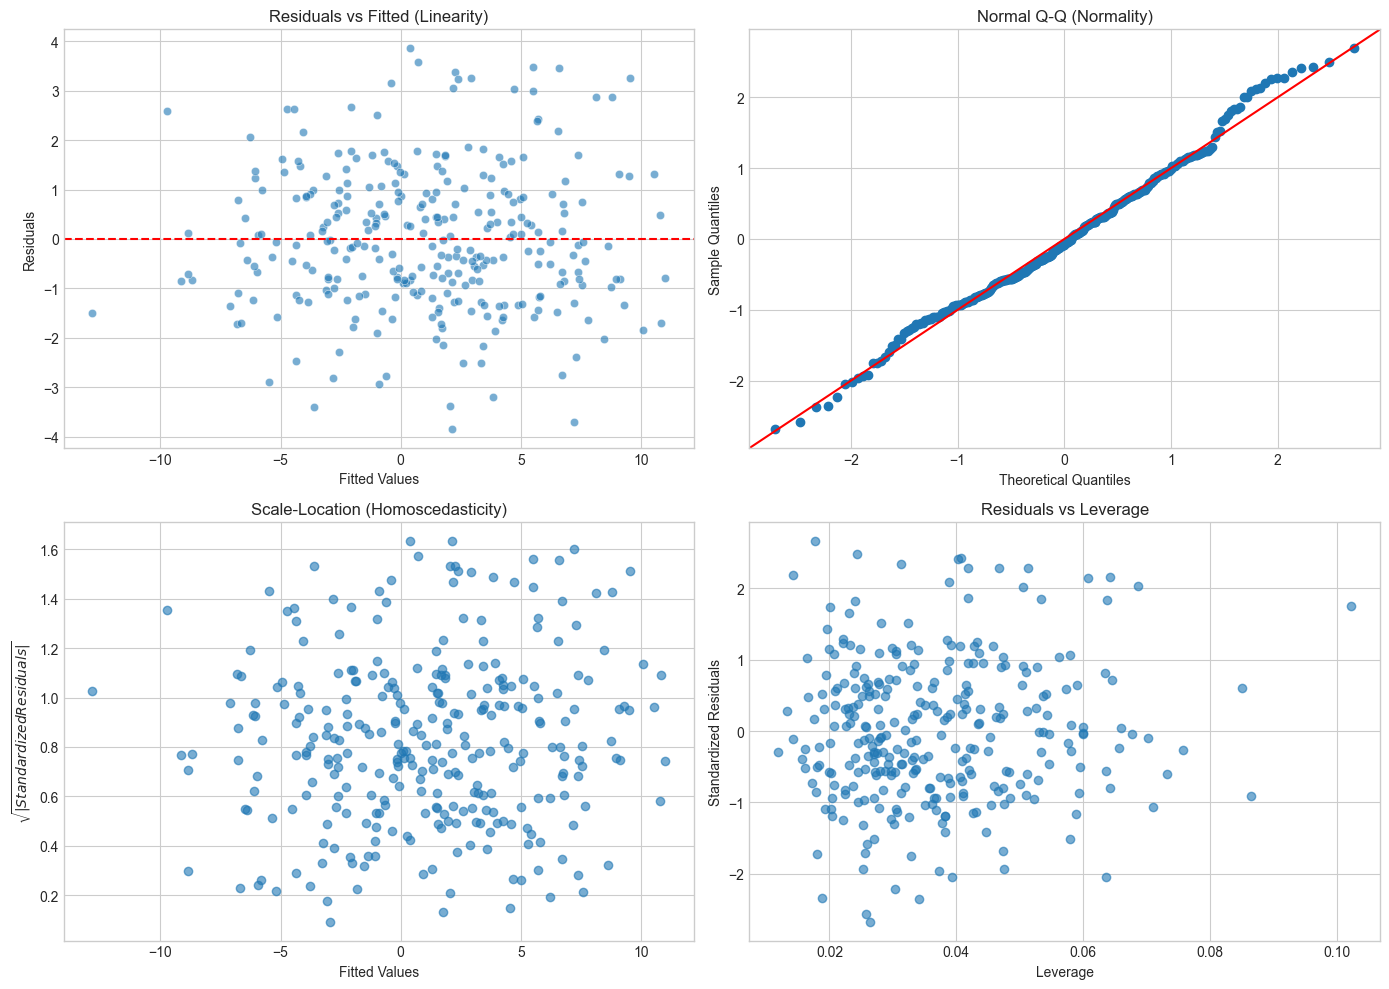

In [6]:
# Diagnostic Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
residuals = model_ols.resid
fitted = model_ols.fittedvalues
norm_resid = model_ols.get_influence().resid_studentized_internal

# 1. Residuals vs Fitted
sns.scatterplot(x=fitted, y=residuals, ax=axes[0,0], alpha=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals vs Fitted (Linearity)')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')

# 2. Normal Q-Q
sm.qqplot(residuals, line='45', fit=True, ax=axes[0,1])
axes[0,1].set_title('Normal Q-Q (Normality)')

# 3. Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(norm_resid)), alpha=0.6)
axes[1,0].set_title('Scale-Location (Homoscedasticity)')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('$\sqrt{|Standardized Residuals|}$')

# 4. Residuals vs Leverage
influence = model_ols.get_influence()
leverage = influence.hat_matrix_diag
axes[1,1].scatter(leverage, norm_resid, alpha=0.6)
axes[1,1].set_title('Residuals vs Leverage')
axes[1,1].set_xlabel('Leverage')
axes[1,1].set_ylabel('Standardized Residuals')

plt.tight_layout()
plt.show()

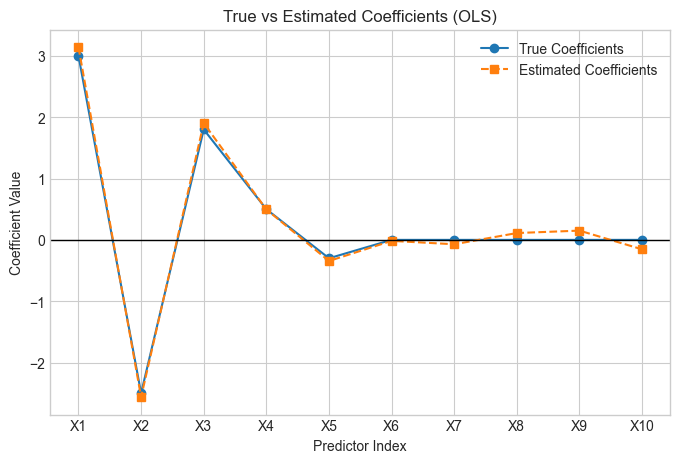

In [14]:
plt.figure(figsize=(8,5))
plt.plot(beta_true, 'o-', label='True Coefficients')
plt.plot(model_ols.params[1:], 's--', label='Estimated Coefficients')
plt.axhline(0, color='black', linewidth=1)
plt.title("True vs Estimated Coefficients (OLS)")
plt.xlabel("Predictor Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()



To validate the reliability of the OLS model, we examine the residuals and assess the classical linear regression assumptions.

### Diagnostic Interpretation

**Residuals vs Fitted**  
The residuals are randomly scattered around zero with no clear pattern.  
This suggests that the linearity assumption is satisfied and no major non-linear structure is missing.

**Normal Q–Q Plot**  
The residuals approximately follow the reference line.  
This indicates that the error terms are reasonably normally distributed.

**Scale–Location Plot**  
The spread of residuals remains fairly constant across fitted values.  
This supports the homoscedasticity assumption (constant variance).

**Residuals vs Leverage**  
No observations show extremely high leverage or influence.  
This means no single data point is disproportionately affecting the model estimates.

**Conclusion**  
Overall, the diagnostic checks confirm that the assumptions of the linear regression model are reasonably satisfied.

 Ridge Regression (L2 Regularization)

Ridge regression introduces a penalty on the squared magnitude of the coefficients.  
The regularization parameter (lambda) is selected using cross-validation.



<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11436\4090711885.py:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.axvline(ridge_cv.alpha_, color='k', linestyle='--', label=f'Optimal $\lambda$={ridge_cv.alpha_:.2f}')


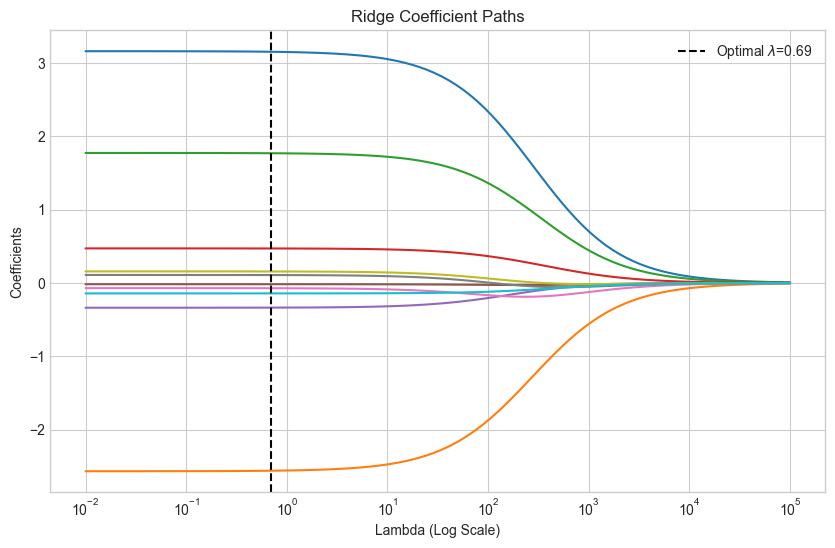

Ridge Optimal Lambda: 0.69
Ridge Coefficients:
[ 3.153 -2.559  1.77   0.471 -0.335 -0.016 -0.071  0.109  0.158 -0.141]


In [7]:
# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_X)

# Define Alphas (Lambdas)
alphas = np.logspace(-2, 5, 100)

# Ridge with Cross-Validation
ridge_cv = RidgeCV(alphas=alphas).fit(X_scaled, y)

# Compute Paths for Plotting
ridge_coefs = [Ridge(alpha=a).fit(X_scaled, y).coef_ for a in alphas]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.axvline(ridge_cv.alpha_, color='k', linestyle='--', label=f'Optimal $\lambda$={ridge_cv.alpha_:.2f}')
plt.title('Ridge Coefficient Paths')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Coefficients')
plt.legend()
plt.show()

print(f"Ridge Optimal Lambda: {ridge_cv.alpha_:.2f}")
print(f"Ridge Coefficients:\n{np.round(ridge_cv.coef_, 3)}")

### Interpretation

As lambda increases, all coefficients gradually shrink toward zero.  
However, none of the coefficients become exactly zero.

Strong predictors remain relatively large, while noise predictors are heavily reduced but still present.

Ridge improves numerical stability and reduces variance, especially when predictors are correlated.  
However, it does not perform variable selection.

---

Lasso Regression (L1 Regularization)

Lasso regression applies a penalty on the absolute value of the coefficients.  
The optimal lambda is selected via cross-validation.

<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11436\1933717338.py:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.axvline(lasso_cv.alpha_, color='k', linestyle='--', label=f'Optimal $\lambda$={lasso_cv.alpha_:.4f}')
c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


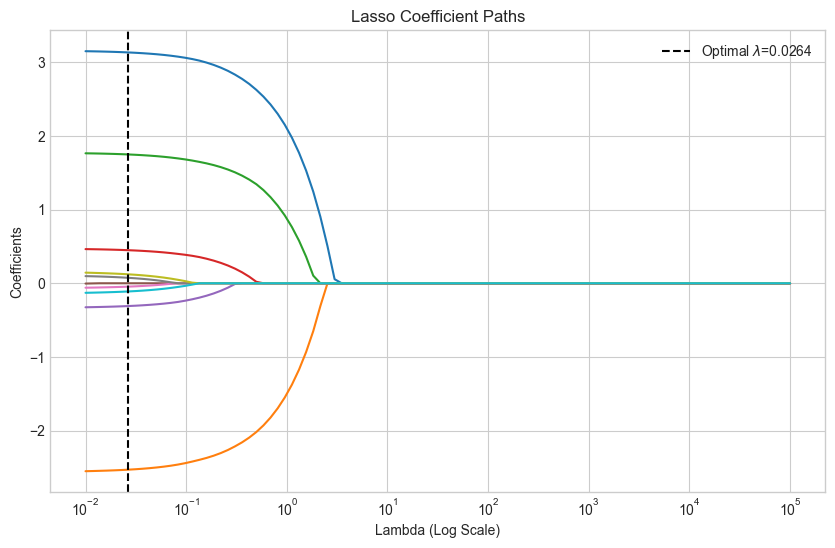

Lasso Optimal Lambda: 0.0264
Lasso Coefficients:
[ 3.135 -2.531  1.749  0.449 -0.31  -0.    -0.046  0.074  0.122 -0.111]


In [8]:
# Lasso with Cross-Validation
lasso_cv = LassoCV(alphas=None, cv=10, random_state=42).fit(X_scaled, y)

# Compute Paths
from sklearn.linear_model import lasso_path
l_alphas, l_coefs, _ = lasso_path(X_scaled, y, alphas=alphas)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(l_alphas, l_coefs.T)
plt.xscale('log')
plt.axvline(lasso_cv.alpha_, color='k', linestyle='--', label=f'Optimal $\lambda$={lasso_cv.alpha_:.4f}')
plt.title('Lasso Coefficient Paths')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Coefficients')
plt.legend()
plt.show()

print(f"Lasso Optimal Lambda: {lasso_cv.alpha_:.4f}")
print(f"Lasso Coefficients:\n{np.round(lasso_cv.coef_, 3)}")

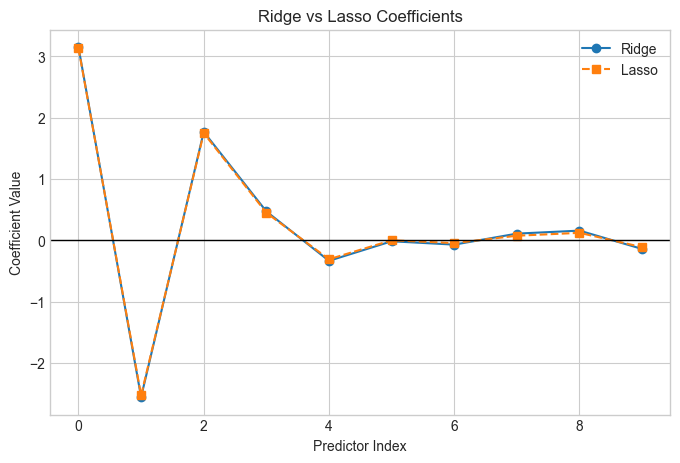

In [15]:
plt.figure(figsize=(8,5))
plt.plot(ridge_cv.coef_, 'o-', label='Ridge')
plt.plot(lasso_cv.coef_, 's--', label='Lasso')
plt.axhline(0, color='black', linewidth=1)
plt.title("Ridge vs Lasso Coefficients")
plt.xlabel("Predictor Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()

Interpretation

As the penalty increases, some coefficients shrink exactly to zero.

Irrelevant predictors (X6 to X10) are eliminated from the model.  
Strong predictors (X1 to X3) remain non-zero.

Lasso performs automatic variable selection and produces a more interpretable model.

Conclusion: Lasso is particularly effective when the true model is sparse.

---

## Elastic Net Regression

Elastic Net combines both L1 and L2 penalties.  
It balances shrinkage (Ridge) and sparsity (Lasso).


In [9]:
# Elastic Net with Cross-Validation for both Alpha and Lambda
enet_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=10, random_state=42)
enet_cv.fit(X_scaled, y)

print(f"Optimal L1 Ratio: {enet_cv.l1_ratio_}")
print(f"Optimal Lambda: {enet_cv.alpha_:.4f}")
print(f"Elastic Net Coefficients:\n{np.round(enet_cv.coef_, 3)}")

Optimal L1 Ratio: 1.0
Optimal Lambda: 0.0264
Elastic Net Coefficients:
[ 3.135 -2.531  1.749  0.449 -0.31  -0.    -0.046  0.074  0.122 -0.111]


Interpretation

Elastic Net selects important predictors while maintaining coefficient stability.

When predictors are independent, Elastic Net behaves similarly to Lasso.  
When predictors are correlated, it tends to select groups of related variables together.

This method provides a compromise between Ridge and Lasso.

### Comparison of Regularization Methods

- OLS provides unbiased estimates but may suffer from higher variance.
- Ridge reduces variance but keeps all predictors.
- Lasso performs variable selection by shrinking some coefficients to zero.
- Elastic Net balances stability and sparsity.

Regularization helps control model complexity and improves generalization performance.

 Non-Linear Data Generation

A small dataset (n = 10) is generated from a non-linear function.

Random noise is added to simulate real-world variability.

The observed points deviate from the true function due to randomness, making the underlying pattern more difficult to estimate.

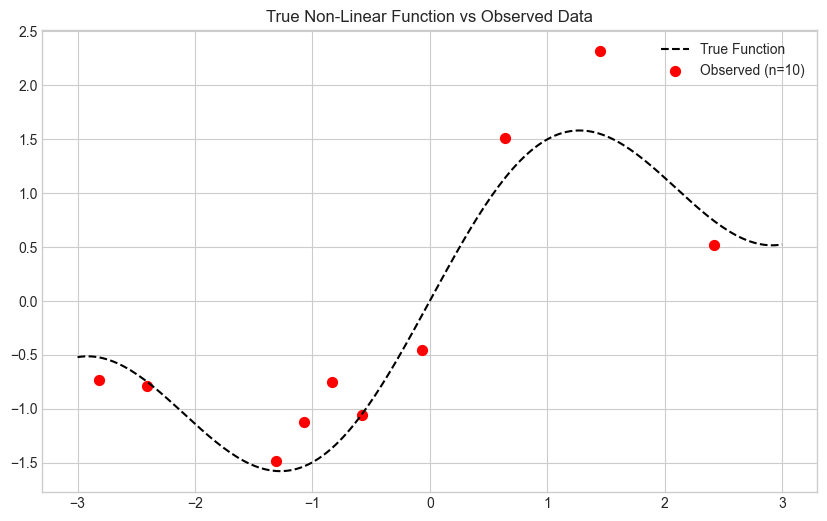

In [10]:
# 3.1 Data Generation
n_small = 10
X_nonlin = np.sort(np.random.uniform(-3, 3, n_small))

# True Function
def true_func(x):
    return np.sin(1.5 * x) + 0.5 * x

# Response with noise
y_nonlin = true_func(X_nonlin) + np.random.normal(0, 0.3, n_small)

# Visualization Grid
X_grid = np.linspace(-3, 3, 200)

plt.figure(figsize=(10, 6))
plt.plot(X_grid, true_func(X_grid), 'k--', label='True Function')
plt.scatter(X_nonlin, y_nonlin, color='red', s=50, label='Observed (n=10)')
plt.title('True Non-Linear Function vs Observed Data')
plt.legend()
plt.show()

Polynomial Regression and Overfitting

Two polynomial models are fitted:

- Degree 3 (moderate complexity)
- Degree 10 (high complexity)


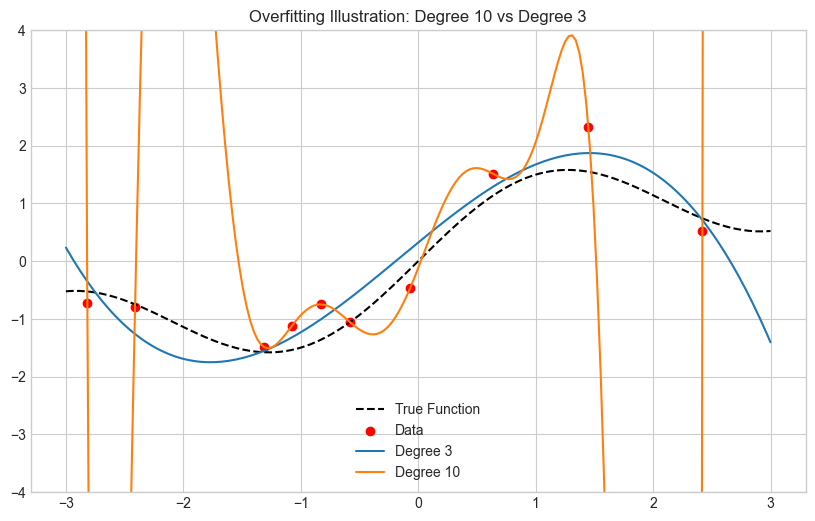

In [11]:
# Pipelines
poly3 = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly3.fit(X_nonlin.reshape(-1, 1), y_nonlin)

poly10 = make_pipeline(PolynomialFeatures(10), LinearRegression())
poly10.fit(X_nonlin.reshape(-1, 1), y_nonlin)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(X_grid, true_func(X_grid), 'k--', label='True Function')
plt.scatter(X_nonlin, y_nonlin, color='red', label='Data')
plt.plot(X_grid, poly3.predict(X_grid.reshape(-1, 1)), label='Degree 3')
plt.plot(X_grid, poly10.predict(X_grid.reshape(-1, 1)), label='Degree 10')
plt.ylim(-4, 4)
plt.title('Overfitting Illustration: Degree 10 vs Degree 3')
plt.legend()
plt.show()

Interpretation

Degree 10 perfectly fits the training data and achieves very low training error.  
However, it shows strong oscillations between points, indicating overfitting.

Degree 3 provides a smoother approximation of the true function.  
Although it has slightly higher training error, it generalizes better.

This illustrates the bias-variance trade-off.

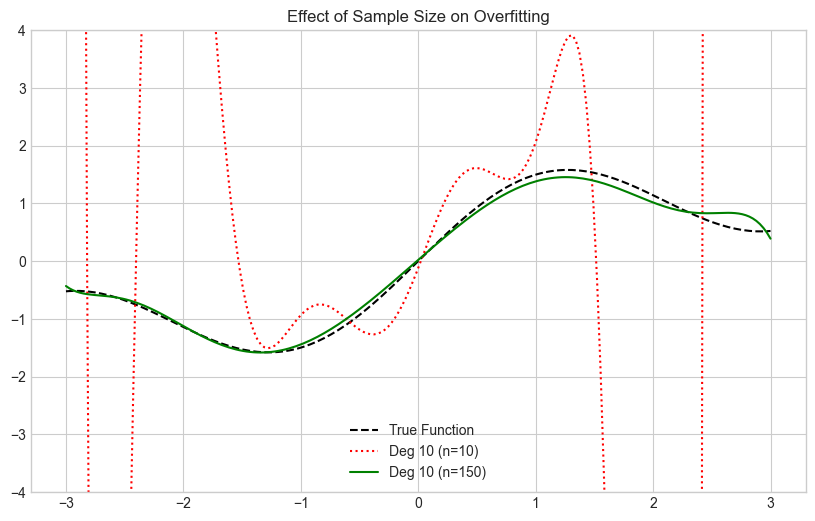

In [12]:
# Simulate Large N
n_large = 150
X_large = np.sort(np.random.uniform(-3, 3, n_large))
y_large = true_func(X_large) + np.random.normal(0, 0.3, n_large)

# Refit Degree 10
poly10_large = make_pipeline(PolynomialFeatures(10), LinearRegression())
poly10_large.fit(X_large.reshape(-1, 1), y_large)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(X_grid, true_func(X_grid), 'k--', label='True Function')
plt.plot(X_grid, poly10.predict(X_grid.reshape(-1, 1)), 'r:', label='Deg 10 (n=10)')
plt.plot(X_grid, poly10_large.predict(X_grid.reshape(-1, 1)), 'g-', label='Deg 10 (n=150)')
plt.ylim(-4, 4)
plt.title('Effect of Sample Size on Overfitting')
plt.legend()
plt.show()

Effect of Increasing Sample Size

When the sample size increases (n = 150):

- The degree 10 polynomial becomes smoother.
- Extreme oscillations are reduced.
- Overfitting becomes less severe.

Larger datasets reduce variance and improve model stability.
---

3.4 Comparison of Non-Linear Models

Two alternative models are applied:

**Decision Tree**
- Produces a piecewise constant (step-like) function.
- Captures the general trend but lacks smoothness.

**Support Vector Regression (SVR)**
- Uses an RBF kernel to model smooth non-linear relationships.
- Produces a continuous and stable curve.

### Conclusion

For a smooth underlying function, SVR provides a closer approximation than the Decision Tree.

Model choice should depend on the structure of the data and the desired level of flexibility.

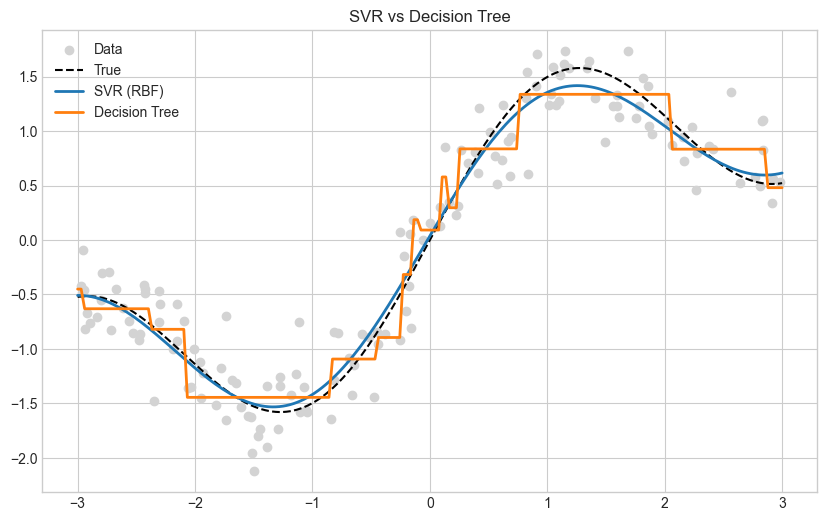

In [13]:
# 1. SVR (RBF Kernel)
svr = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr.fit(X_large.reshape(-1, 1), y_large)

# 2. Decision Tree
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_large.reshape(-1, 1), y_large)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_large, y_large, color='lightgray', label='Data')
plt.plot(X_grid, true_func(X_grid), 'k--', label='True')
plt.plot(X_grid, svr.predict(X_grid.reshape(-1, 1)), label='SVR (RBF)', linewidth=2)
plt.plot(X_grid, tree.predict(X_grid.reshape(-1, 1)), label='Decision Tree', linewidth=2)
plt.title('SVR vs Decision Tree')
plt.legend()
plt.show()

## Conclusion

This assignment demonstrates how regression models behave under controlled simulation.

Linear regression successfully recovers the true structure when assumptions hold.

Regularization techniques improve stability and enable variable selection.

In non-linear settings, excessive model complexity leads to overfitting.

The bias-variance trade-off highlights the importance of balancing flexibility and generalization.